In [1]:
import scanpy as sc
import squidpy as sq

In [9]:
sc.read_h5ad("../out/stf/tfa_all.h5ad").obs.groupby("sample_id")["pred_cor" ,"pred_cor_stl" ,"pred_cor_loc_perm","pred_cor_gene_perm" ].mean().round(3)

<ipython-input-9-ecf8a6212585>:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  sc.read_h5ad("../out/stf/tfa_all.h5ad").obs.groupby("sample_id")["pred_cor" ,"pred_cor_stl" ,"pred_cor_loc_perm","pred_cor_gene_perm" ].mean().round(3)


,pred_cor,pred_cor_stl,pred_cor_loc_perm,pred_cor_gene_perm
sample_id,,,,
ER_0,0.174,0.164,0.174,0.006
ER_1,0.176,0.168,0.173,-0.023
ER_2,0.213,0.197,0.210,-0.002
HER2_0,0.161,0.147,0.160,-0.001
HER2_1,0.190,0.187,0.188,0.004
HER2_2,0.184,0.177,0.182,-0.005
HER2_3,0.156,0.152,0.155,-0.003
HER2_4,0.208,0.201,0.208,-0.004
HER2_5,0.184,0.174,0.183,-0.017


In [10]:
sc.read_h5ad("../out/stf/tfa_all.h5ad").obs.groupby("sample_id")['source'].first()

sample_id
ER_0             Wu2021
ER_1             Wu2021
ER_2        10xGenomics
HER2_0    Andersson2021
HER2_1    Andersson2021
HER2_2    Andersson2021
HER2_3    Andersson2021
HER2_4    Andersson2021
HER2_5    Andersson2021
HER2_6    Andersson2021
HER2_7    Andersson2021
TNBC_0           Wu2021
TNBC_1           Wu2021
TNBC_2           Wu2021
TNBC_3           Wu2021
Name: source, dtype: object

In [12]:
adata_raw=sc.read_h5ad("../data/10xGenomics/Section_2.h5ad")

In [11]:
adata_tfa=sc.read_h5ad("../out/stf/Section_2_tfa_only.h5ad")
adata_tfa.layers["tf_mRNA"]=adata_tfa.layers["tf_mRNA"].astype(float)

In [13]:
adata_tfa.uns=adata_raw.uns

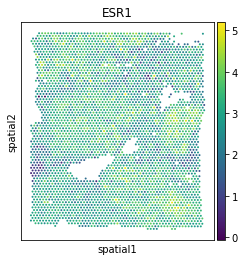

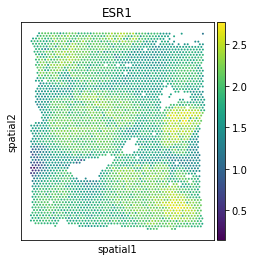

In [160]:
from matplotlib import pyplot as plt
tf="ESR1"
ct="Epithelial"
%matplotlib 
fig, axs=plt.subplots(3,4, figsize=(20,10))

sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype_major"),
              color=ct, layer='tf_mRNA', alpha_img=0, ax=axs[0,0],show=False, cmap="inferno", size=1.5)
sc.pl.spatial(adata_tfa, color=tf, layer='tfa', alpha_img=0, ax=axs[0,1],show=False, cmap="plasma", size=1.5, title=tf+" (STAN)")
sc.pl.spatial(adata_tfa, color=tf, layer='tfa_stl', alpha_img=0, ax=axs[0,2],show=False, cmap="plasma", size=1.5, title=tf+" (Ridge Regression)")
sc.pl.spatial(adata_tfa, color=tf, layer='tf_mRNA', alpha_img=0, ax=axs[0,3],show=False, size=1.5, title=tf+" (mRNA)")

tf="CDK7"
ct="Lymphocytes"

sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype_major"),
              color=ct, layer='tf_mRNA', alpha_img=0, ax=axs[1,0],show=False, cmap="inferno", size=1.5)
sc.pl.spatial(adata_tfa, color=tf, layer='tfa', alpha_img=0, ax=axs[1,1],show=False, cmap="plasma", size=1.5, title=tf+" (STAN)")
sc.pl.spatial(adata_tfa, color=tf, layer='tfa_stl', alpha_img=0, ax=axs[1,2],show=False, cmap="plasma", size=1.5, title=tf+" (Ridge Regression)")
sc.pl.spatial(adata_tfa, color=tf, layer='tf_mRNA', alpha_img=0, ax=axs[1,3],show=False, size=1.5, title=tf+" (mRNA)")

tf="PBX1"
ct="Myeloid"


sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype_major"),
              color=ct, layer='tf_mRNA', alpha_img=0, ax=axs[2,0],show=False, cmap="inferno", size=1.5)
sc.pl.spatial(adata_tfa, color=tf, layer='tfa', alpha_img=0, ax=axs[2,1],show=False, cmap="plasma", size=1.5, title=tf+" (STAN)")
sc.pl.spatial(adata_tfa, color=tf, layer='tfa_stl', alpha_img=0, ax=axs[2,2],show=False, cmap="plasma", size=1.5, title=tf+" (Ridge Regression)")
sc.pl.spatial(adata_tfa, color=tf, layer='tf_mRNA', alpha_img=0, ax=axs[2,3],show=False, size=1.5, title=tf+" (mRNA)")

for ax in axs.flatten():
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

Using matplotlib backend: MacOSX


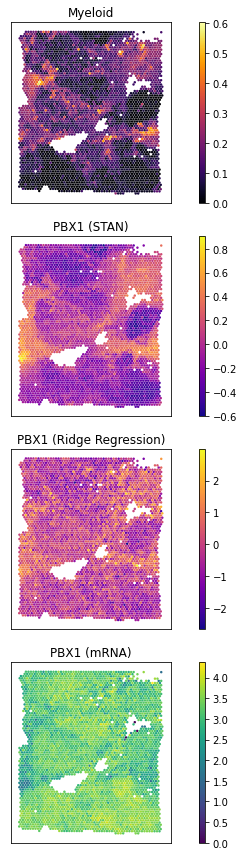

In [102]:
tf="PBX1"
ct="Myeloid"
fig, axs=plt.subplots(4,1, figsize=(40,12))
sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype_major"),
              color=ct, layer='tf_mRNA', alpha_img=0, ax=axs[0],show=False, cmap="inferno", size=1.5)
sc.pl.spatial(adata_tfa, color=tf, layer='tfa', alpha_img=0, ax=axs[1],show=False, cmap="plasma", size=1.5, title=tf+" (STAN)")
sc.pl.spatial(adata_tfa, color=tf, layer='tfa_stl', alpha_img=0, ax=axs[2],show=False, cmap="plasma", size=1.5, title=tf+" (Ridge Regression)")
sc.pl.spatial(adata_tfa, color=tf, layer='tf_mRNA', alpha_img=0, ax=axs[3],show=False, size=1.5, title=tf+" (mRNA)")

for ax in axs:
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()

In [98]:
adata_tfa.to_df().corrwith(adata_tfa.obsm['celltype_major']['Myeloid']).sort_values().tail(20)

BCL11A    0.521026
MYC       0.522538
PPARG     0.523704
STAG1     0.534393
NFIC      0.536447
FOXP3     0.544732
SP1       0.550869
EBF1      0.572626
HOXA1     0.575099
RAD21     0.584232
WDR5      0.594764
CBFB      0.600725
NCOR2     0.628606
SPIB      0.644233
RFX5      0.646616
RXRG      0.650050
MYH11     0.654696
CIITA     0.655896
EWSR1     0.658563
PBX1      0.664917
dtype: float64

In [96]:
adata_tfa.obsm['celltype_major']

,CAFs,Endothelial,Myeloid,PVL,Plasma Cells,Epithelial,Lymphocytes
Section_2_AAACAACGAATAGTTC-1,0.049465,8.077858e-02,0.161025,7.624862e-02,3.361407e-02,0.440925,0.157943
Section_2_AAACAAGTATCTCCCA-1,0.166921,3.064817e-02,0.371368,1.889982e-02,1.417106e-01,0.156123,0.114329
Section_2_AAACAATCTACTAGCA-1,0.014490,1.180646e-02,0.087974,2.188324e-02,5.792237e-11,0.756789,0.107058
Section_2_AAACACCAATAACTGC-1,0.026967,9.299507e-03,0.059016,3.774567e-10,5.734521e-14,0.573998,0.330719
Section_2_AAACAGAGCGACTCCT-1,0.072525,3.136794e-01,0.182149,1.491076e-03,2.394483e-02,0.213376,0.192834
...,...,...,...,...,...,...,...
Section_2_TTGTTTCACATCCAGG-1,0.020018,6.139336e-13,0.076953,4.307905e-10,2.721544e-14,0.412335,0.490694
Section_2_TTGTTTCATTAGTCTA-1,0.015009,1.823225e-02,0.001274,1.874465e-02,6.434122e-13,0.550120,0.396620
Section_2_TTGTTTCCATACAACT-1,0.077141,1.247320e-02,0.307797,3.342744e-02,8.432488e-03,0.430747,0.129982
Section_2_TTGTTTGTATTACACG-1,0.084682,2.690271e-03,0.044381,1.151079e-10,3.272002e-14,0.495175,0.373072


In [107]:
import pandas as pd
pd.read_csv("../out/stf/perf.csv")

,Unnamed: 0,Source,Sample,replicate,Spatial regularizer,Single task learning,Permuted Genes,Single task learning p-value,Permuted Genes p-value
0,A2,Andersson2021,A,A2,0.111067,0.097022,0.005925,1.000261e-54,5.265595e-55
1,1160920F,Wu2021,1160920F,1160920F,0.185790,0.138830,0.002125,0.000000e+00,0.000000e+00
2,CID44971,Wu2021,CID44971,CID44971,0.167178,0.118035,0.002540,2.291251e-179,2.291251e-179
3,D6,Andersson2021,D,D6,0.180781,0.173669,-0.002100,1.560528e-53,1.560528e-53
4,Section_1,10xGenomics,V1_Breast_Cancer_Block_A,Section_1,0.136878,0.114732,0.009345,0.000000e+00,0.000000e+00
5,B4,Andersson2021,B,B4,0.095389,0.090423,-0.007760,2.364331e-46,3.904281e-48
6,C4,Andersson2021,C,C4,0.177012,0.172700,-0.012778,5.176286e-32,3.018355e-32
7,C5,Andersson2021,C,C5,0.162316,0.162357,-0.008659,9.747745e-01,1.995080e-31
8,B5,Andersson2021,B,B5,0.147502,0.131386,-0.005334,4.525457e-48,4.072280e-49
9,A3,Andersson2021,A,A3,0.154981,0.129484,0.006231,4.091513e-60,2.118904e-60


<AxesSubplot:xlabel='variable', ylabel='value'>

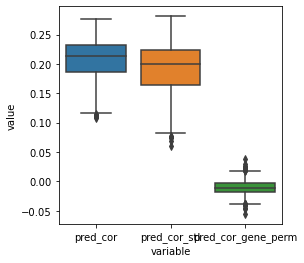

In [130]:
import seaborn as sns
plt.figure(figsize=(4,4))
sns.boxplot(data=adata_tfa.obs[["pred_cor", "pred_cor_stl", "pred_cor_gene_perm"]].melt(), x="variable", y='value')

Index(['CAFs', 'Endothelial', 'Myeloid', 'PVL', 'Plasma Cells', 'Epithelial',
       'Lymphocytes'],
      dtype='object')

In [22]:
%matplotlib
sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype_major"), color=adata_tfa.obsm['celltype_major'].columns, layer='tf_mRNA', alpha_img=0,size=1.5, cmap="inferno")

Using matplotlib backend: MacOSX
